## Libraries and imports

In [1]:
# Libraries

import numpy as np
import pandas as pd
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates


In [2]:
# Get the dataset
dataset_final = pd.read_csv("../data/processed/DatasetMaster.csv")

In [3]:
dataset_final.columns

Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='str')

In [4]:
df_ml = dataset_final.copy()

In [5]:
df_ml.head(3)

,time,temperature_2m,precipitation,relative_humidity_2m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,runoff,et0_fao_evapotranspiration,wind_speed_10m,...,soil_moisture_7_to_28cm_mean_6h,relative_humidity_2m_mean_6h,precipitation_sum_12h,soil_moisture_0_to_7cm_mean_12h,soil_moisture_7_to_28cm_mean_12h,relative_humidity_2m_mean_12h,precipitation_sum_24h,soil_moisture_0_to_7cm_mean_24h,soil_moisture_7_to_28cm_mean_24h,relative_humidity_2m_mean_24h
0,2019-01-02 00:00:00,12.1,0.0,44,0.125,0.138,0.145,NaN,0.00,1.4,...,0.138,35.500000,0.0,0.124583,0.138,25.666667,0.0,0.124083,0.138,38.458333
1,2019-01-02 01:00:00,11.0,0.0,50,0.125,0.138,0.145,NaN,0.00,0.0,...,0.138,40.166667,0.0,0.124667,0.138,28.250000,0.0,0.124167,0.138,37.625000
2,2019-01-02 02:00:00,10.1,0.0,45,0.125,0.138,0.145,NaN,0.01,3.6,...,0.138,43.666667,0.0,0.124750,0.138,30.750000,0.0,0.124250,0.138,36.541667


In [6]:
def split_data(df, split_date='2025-01-01'):

  # One-Hot Encoding the categorical variable for alcaldia
  df_encoded = pd.get_dummies(df, columns=['alcaldia'], drop_first=False, dtype=int)

  # Slicing using the split date
  df_encoded['time'] = pd.to_datetime(df_encoded['time'])

  # Masks to split train and test
  train_mask = df_encoded['time'] < split_date
  test_mask = df_encoded['time'] >= split_date

  # make the splitting of the data
  df_train = df_encoded[train_mask].copy()
  df_test = df_encoded[test_mask].copy()

  # Delete features from train
  columns_to_drop = ['incident', 'time', 'severidad', 'tema_solicitud']

  X_train = df_train.drop(columns=columns_to_drop)
  y_train = df_train['incident']

  X_test = df_test.drop(columns=columns_to_drop)
  y_test = df_test['incident']

  return X_train, X_test, y_train, y_test


In [7]:
X_train, X_test, y_train, y_test = split_data(df_ml)

## EDA

Unique EDA plot that will use both test and train data, the remaining ones will only use train data

In [19]:
def plot_chronological_partition(df_original, validation_date, test_date):

    # Prepare the datetime index on a copy of the original dataframe
    df = df_original.copy()
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    
    # Resample to weekly basis for a clearer view
    weekly_counts = df.resample('W').size()
    
    # Convert boundaries to datetime
    validation_dt = pd.to_datetime(validation_date)
    test_dt = pd.to_datetime(test_date)

    # Three chronological partitions
    train_series = weekly_counts[weekly_counts.index < validation_dt]
    validation_series = weekly_counts[
        (weekly_counts.index >= validation_dt) & 
        (weekly_counts.index < test_dt)
    ]
    test_series = weekly_counts[weekly_counts.index >= test_dt]

    # Lengths / number of observations
    train_len = train_series.sum()
    validation_len = validation_series.sum()
    test_len = test_series.sum()
    
    # Initialize the canvas
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot Training Data
    ax.fill_between(
        train_series.index,
        train_series.values,
        color='#4C72B0',
        alpha=0.6,
        label=f'Training [Size={train_len:,}]'
    )
    ax.plot(
        train_series.index,
        train_series.values,
        color='#4C72B0',
        linewidth=1.5
    )
    
    # Plot Validation Data
    ax.fill_between(
        validation_series.index,
        validation_series.values,
        color='#55A868',
        alpha=0.6,
        label=f'Validation [Size={validation_len:,}]'
    )
    ax.plot(
        validation_series.index,
        validation_series.values,
        color='#55A868',
        linewidth=1.5
    )
    
    # Plot Testing Data
    ax.fill_between(
        test_series.index,
        test_series.values,
        color='#C44E52',
        alpha=0.6,
        label=f'Testing [Size={test_len:,}]'
    )
    ax.plot(
        test_series.index,
        test_series.values,
        color='#C44E52',
        linewidth=1.5
    )

    # Draw chronological boundaries
    ax.axvline(
        validation_dt,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Validation Boundary ({validation_date})'
    )

    ax.axvline(
        test_dt,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Test Boundary ({test_date})'
    )

    # Formatting and titles
    ax.set_title(
        'Fig 1: Chronological Data Partitioning (Train, Validation, Test)',
        fontsize=15,
        fontweight='bold',
        pad=15
    )
    ax.set_ylabel('Weekly Observation Volume', fontweight='bold')
    ax.set_xlabel('Time (Years)', fontweight='bold')
    
    # Format the X-axis to cleanly show years
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    ax.legend(loc='upper left', frameon=True, shadow=True)
    sns.despine()
    
    plt.tight_layout()
    plt.savefig("../plots/EDA_1_Chronological_Split.png", dpi=300, bbox_inches='tight')
    plt.show()

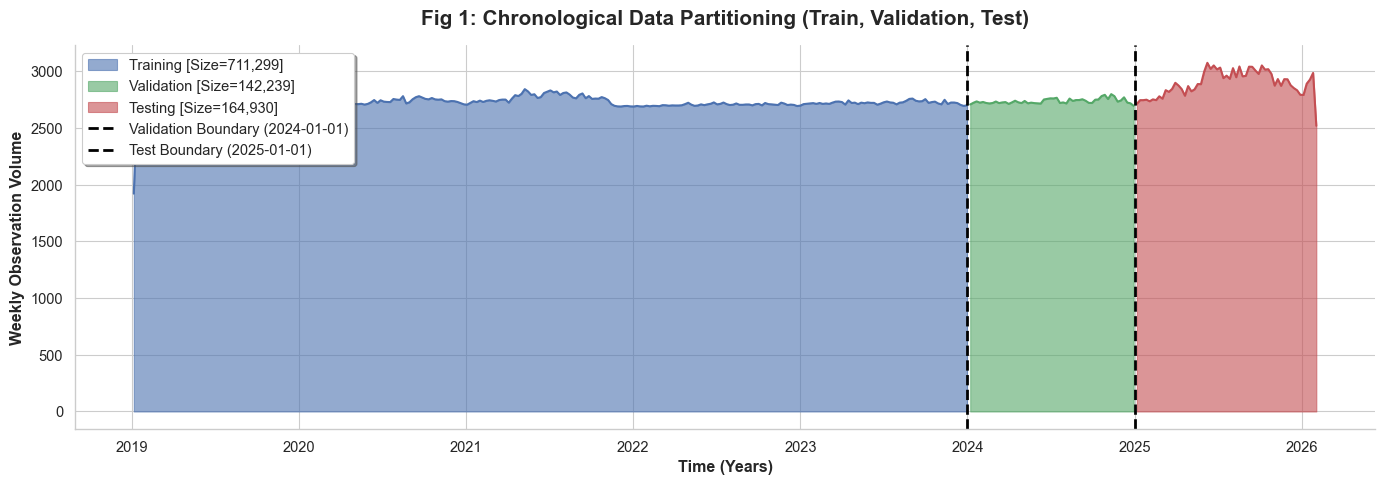

In [20]:
plot_chronological_partition(
    df_ml,
    validation_date='2024-01-01',
    test_date='2025-01-01'
)

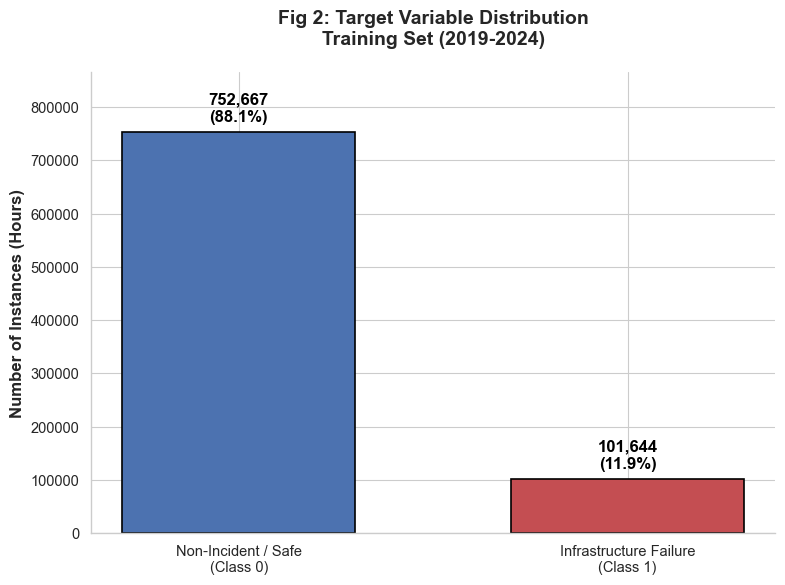

In [9]:
# Imbalance class proof
def plot_target_distribution(y_train):

    # Clean style to the chart
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # Calculate the raw counts and the percentages
    counts = y_train.value_counts().sort_index()
    percentages = y_train.value_counts(normalize=True).sort_index() * 100

    # Initialize the canvas
    fig, ax = plt.subplots(figsize=(8, 6))

    # Setup colors and labels for the bars
    labels = ['Non-Incident / Safe\n(Class 0)', 'Infrastructure Failure\n(Class 1)']
    colors = ['#4C72B0', '#C44E52'] # Muted Blue and Muted Red for better visual distinction

    # Plot the bars
    bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.6)

    # Add the dual-annotations (Count + Percentage)
    for bar, count, percent in zip(bars, counts, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                height + (max(counts) * 0.02), # Slight padding above the bar
                f'{count:,}\n({percent:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    # Formatting and Titles
    ax.set_title('Fig 2: Target Variable Distribution\nTraining Set (2019-2024)',
                 fontsize=14, pad=20, fontweight='bold')
    ax.set_ylabel('Number of Instances (Hours)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.15) #  15% headroom for the text annotations

    # Remove the top and right borders for a cleaner look
    sns.despine()

    # Save the figure at publication quality (300 DPI)
    plt.tight_layout()
    plt.savefig('../plots/EDA_2_Target_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_target_distribution(y_train)

For visual clarity, Figure 2 highlights the density distributions of the variables that exhibited the highest variance during exploratory analysis

Filtered out binary columns. Generating plots for 28 continuous features...
Plotting: temperature_2m...


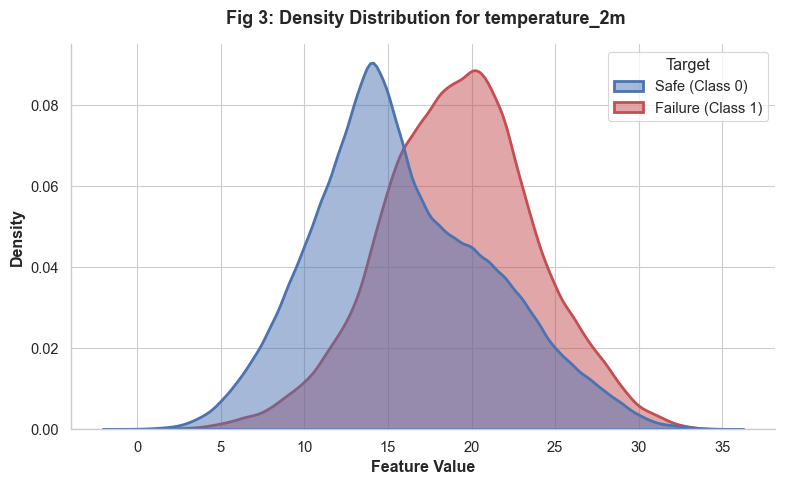

Plotting: precipitation...


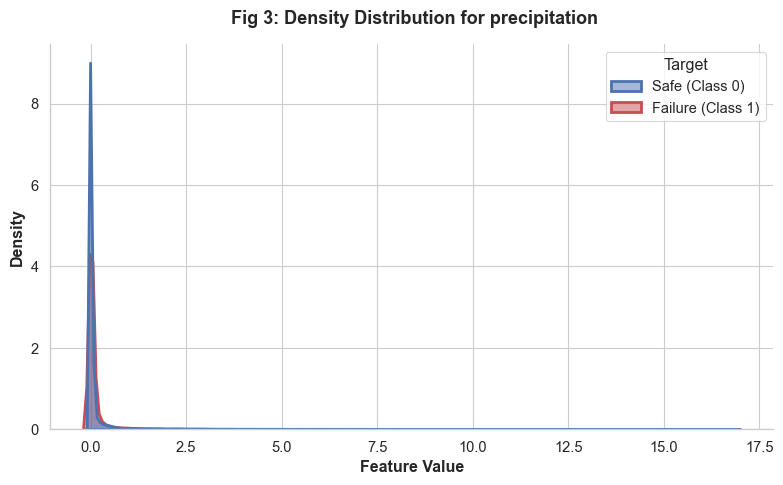

Plotting: relative_humidity_2m...


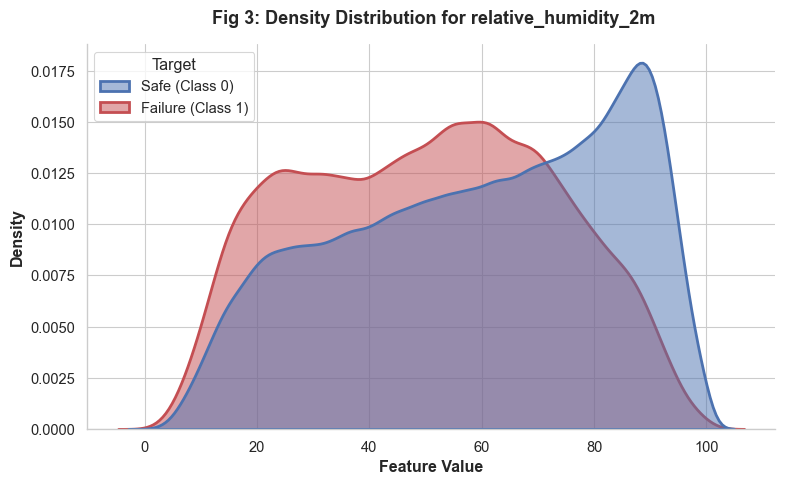

Plotting: soil_moisture_0_to_7cm...


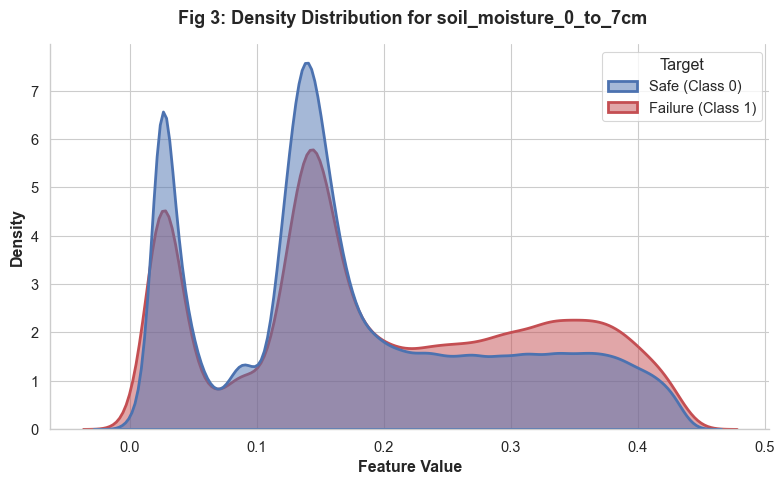

Plotting: soil_moisture_7_to_28cm...


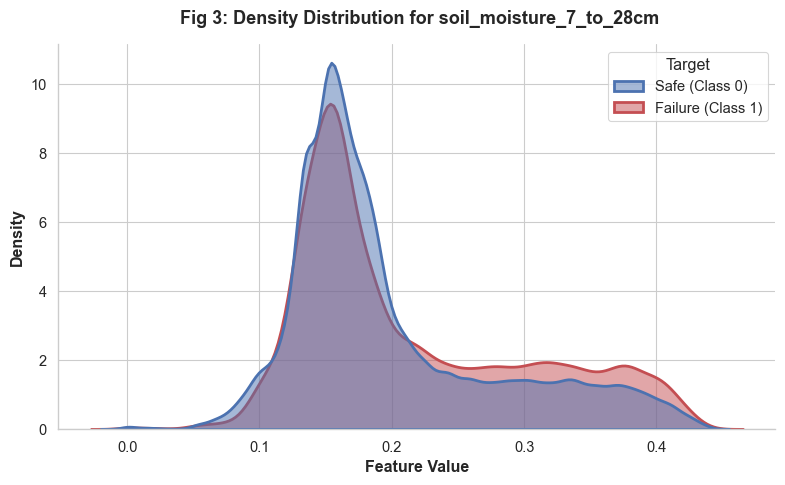

Plotting: soil_moisture_28_to_100cm...


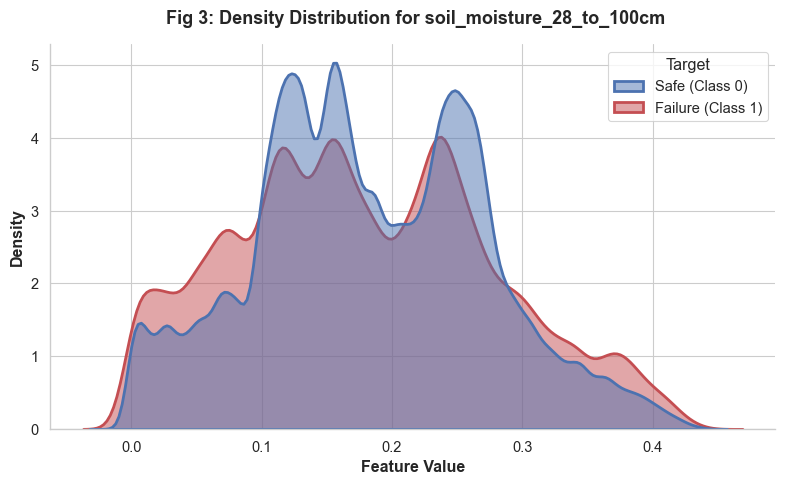

Plotting: et0_fao_evapotranspiration...


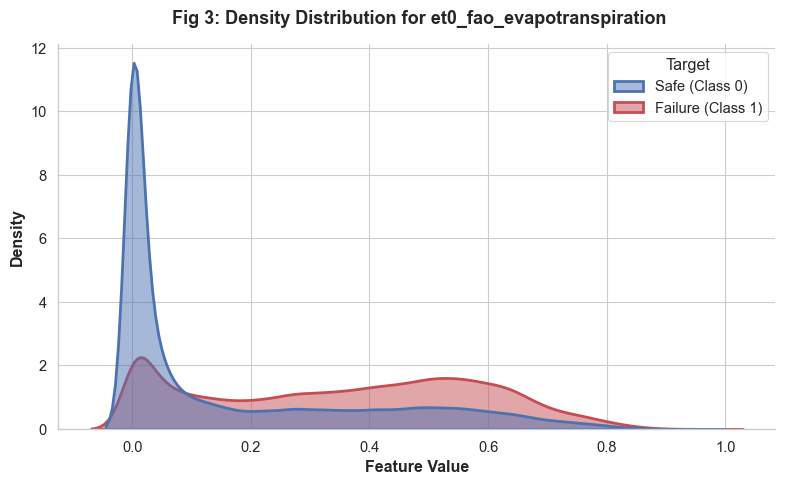

Plotting: wind_speed_10m...


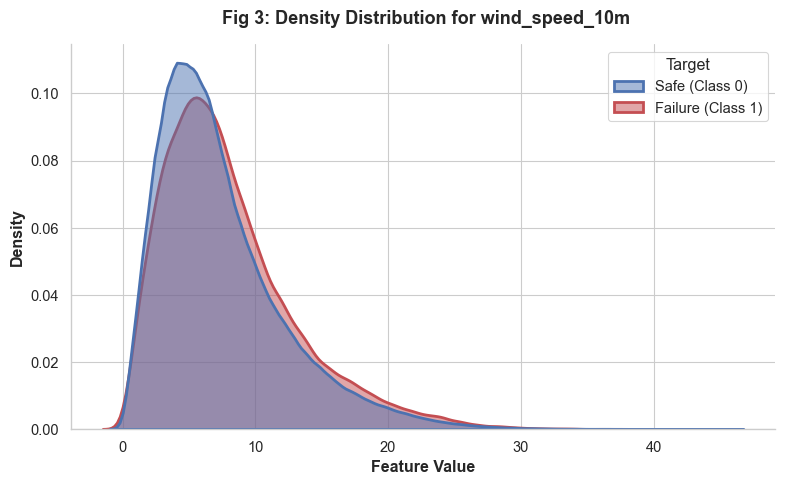

Plotting: wind_gusts_10m...


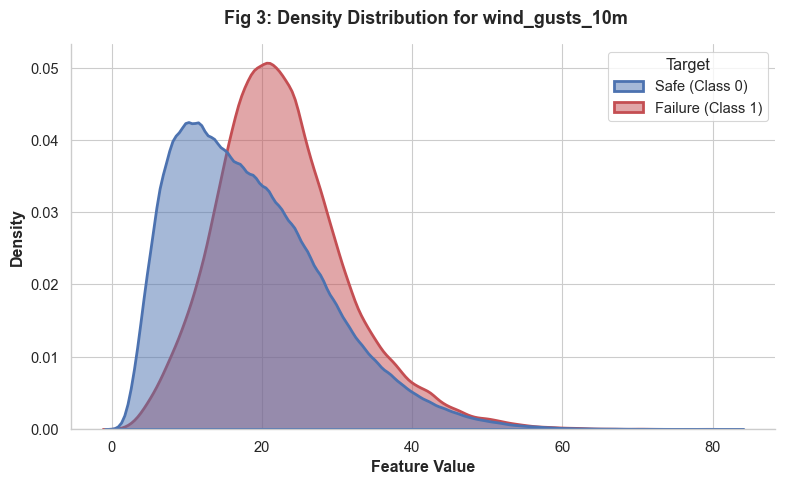

Plotting: mes...


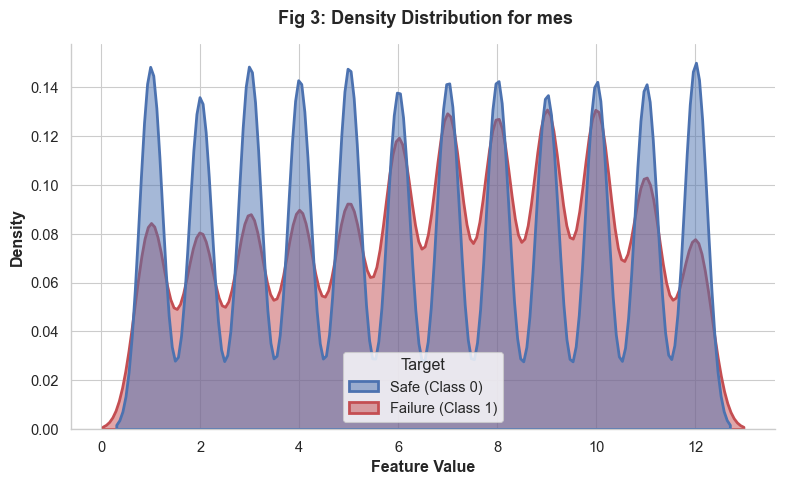

Plotting: dia_semana...


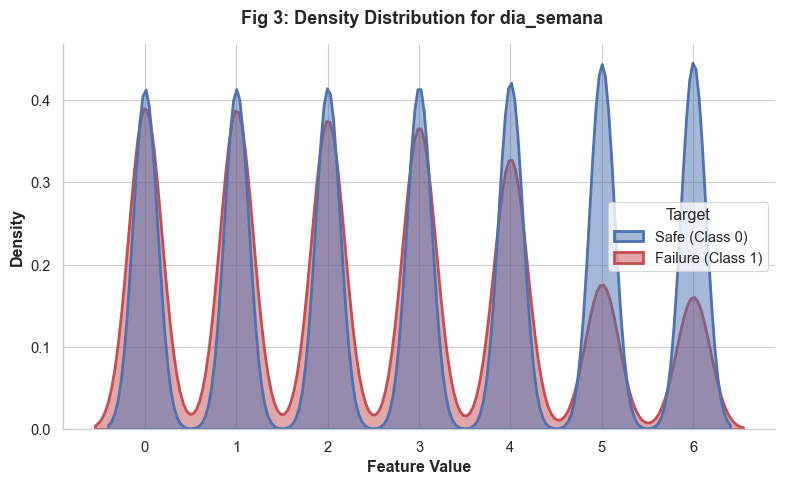

Plotting: hora_del_dia...


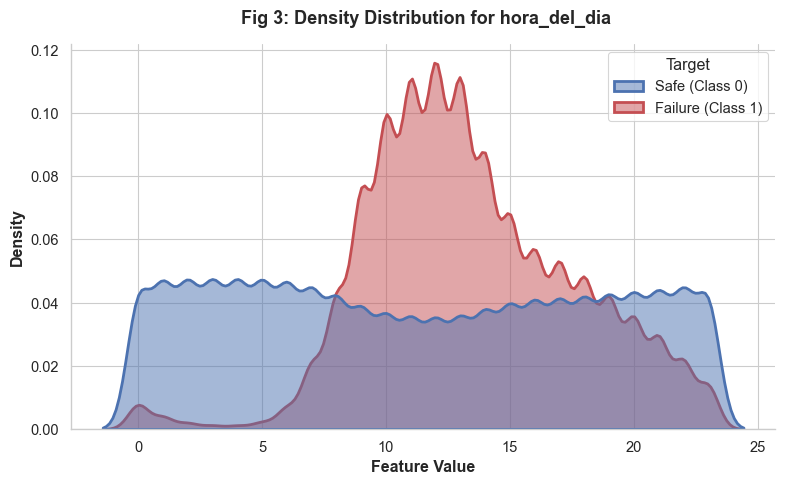

Plotting: precipitation_sum_3h...


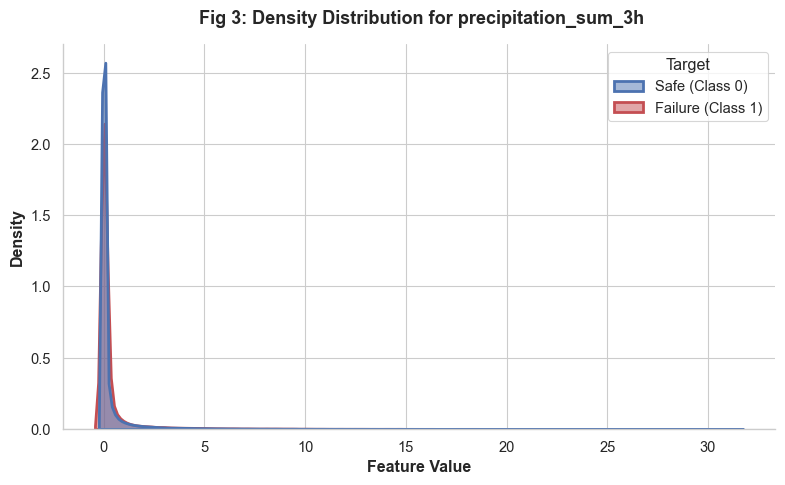

Plotting: soil_moisture_0_to_7cm_mean_3h...


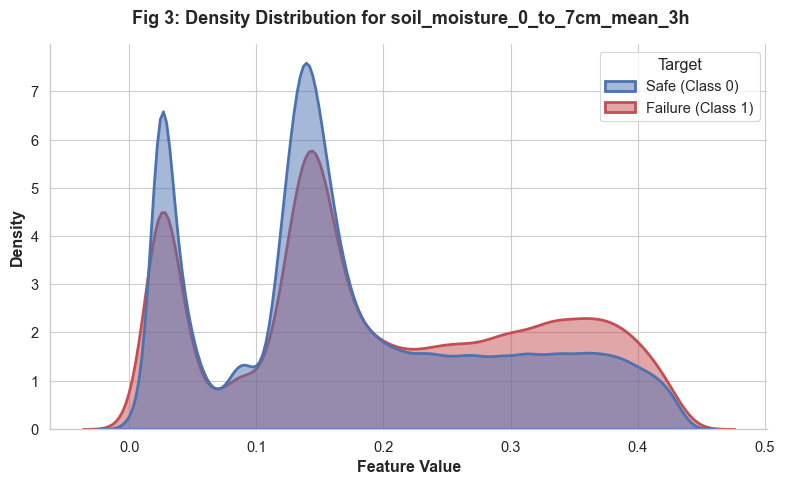

Plotting: soil_moisture_7_to_28cm_mean_3h...


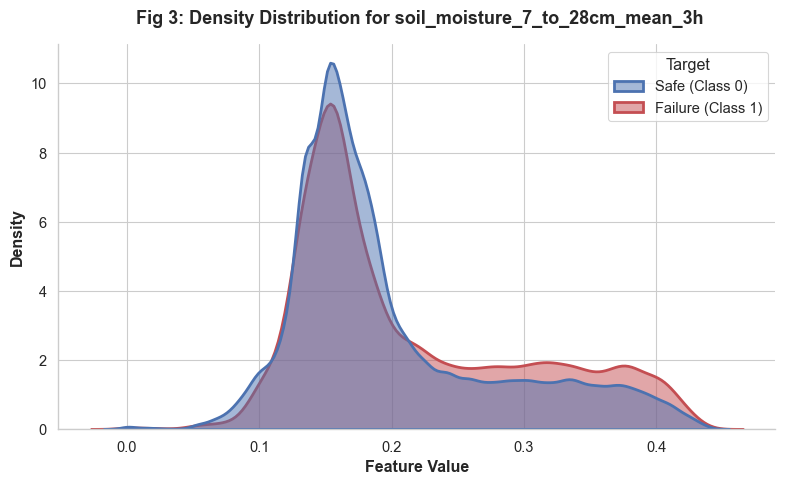

Plotting: relative_humidity_2m_mean_3h...


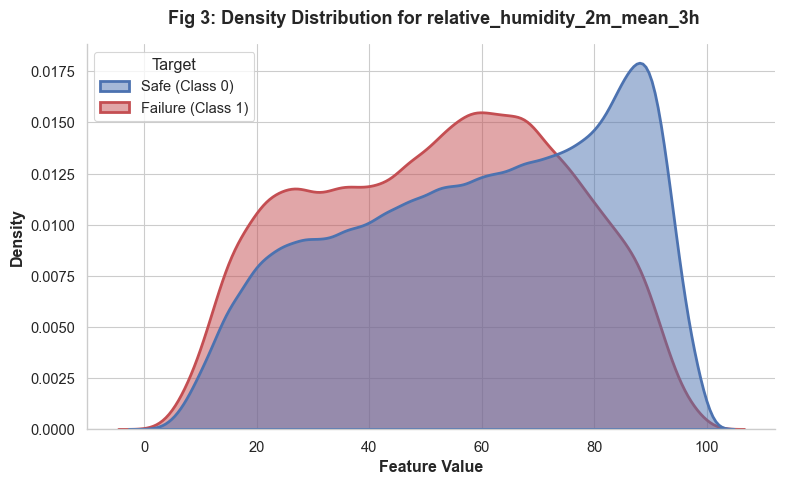

Plotting: precipitation_sum_6h...


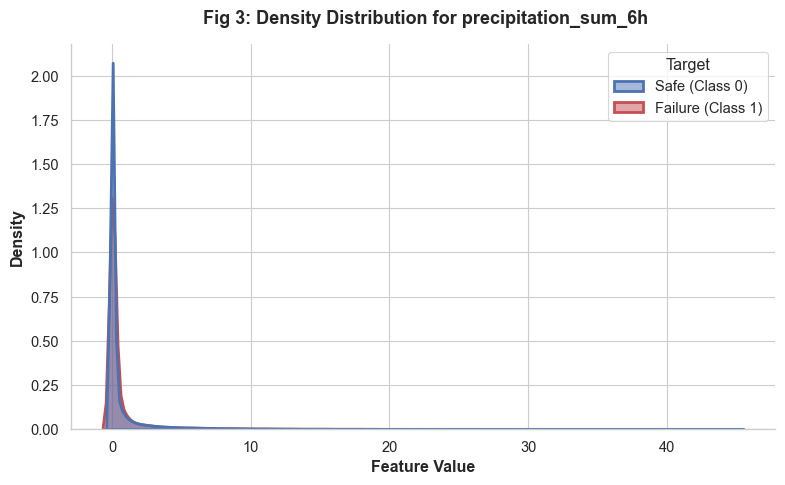

Plotting: soil_moisture_0_to_7cm_mean_6h...


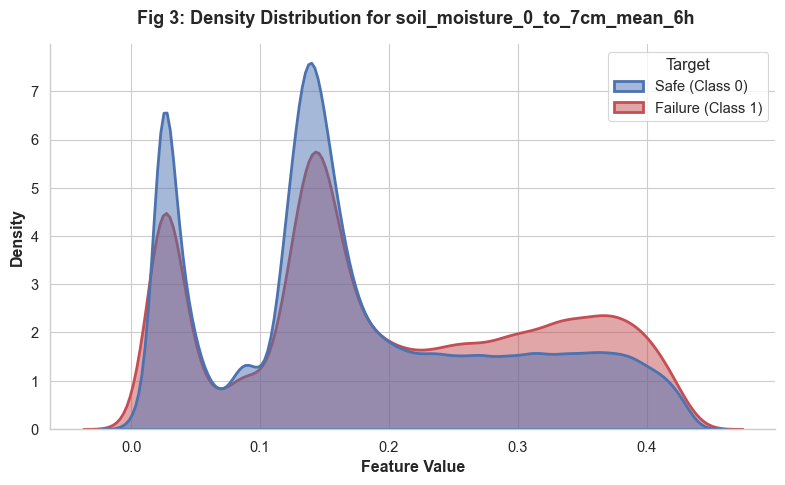

Plotting: soil_moisture_7_to_28cm_mean_6h...


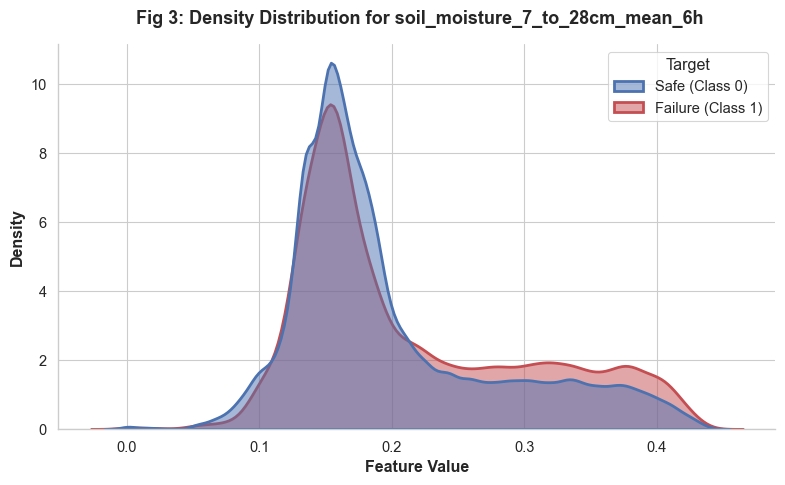

Plotting: relative_humidity_2m_mean_6h...


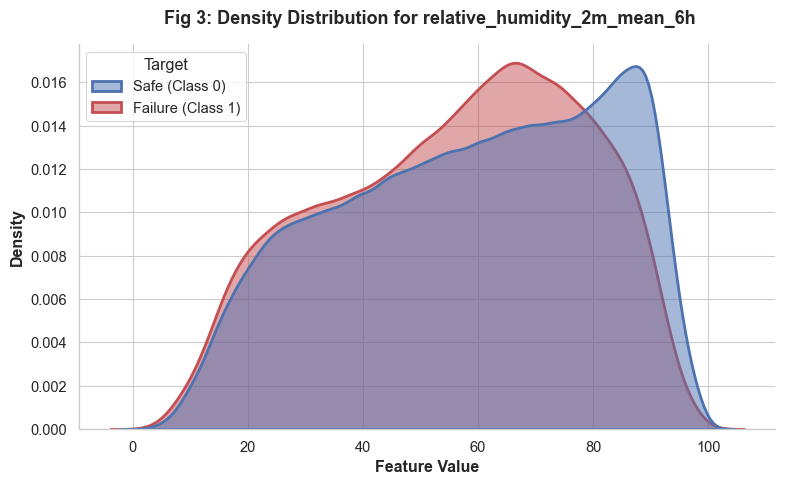

Plotting: precipitation_sum_12h...


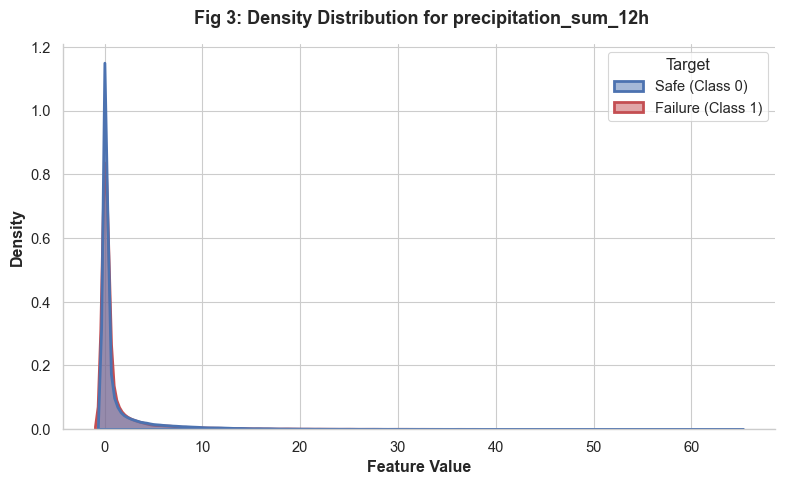

Plotting: soil_moisture_0_to_7cm_mean_12h...


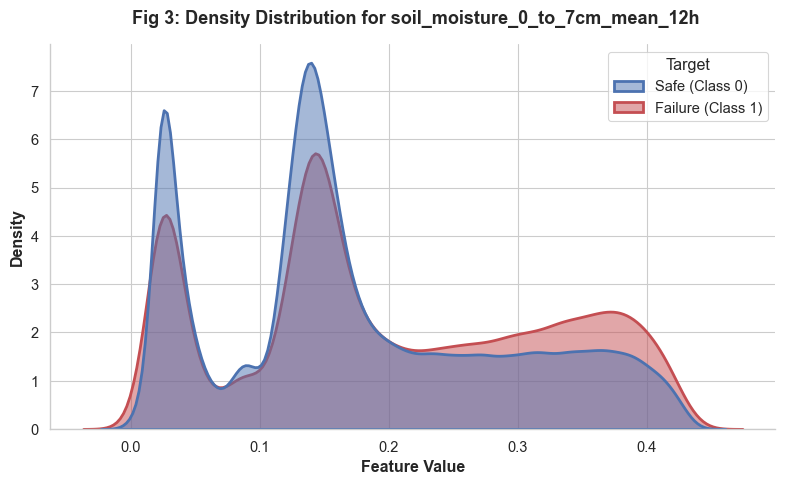

Plotting: soil_moisture_7_to_28cm_mean_12h...


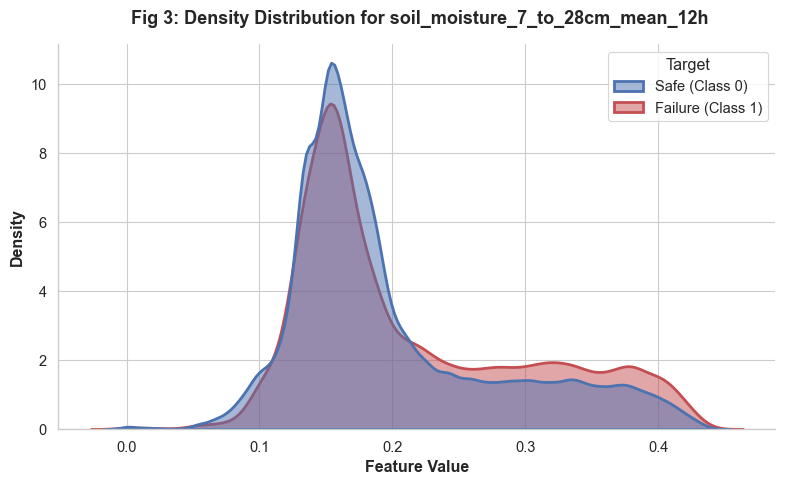

Plotting: relative_humidity_2m_mean_12h...


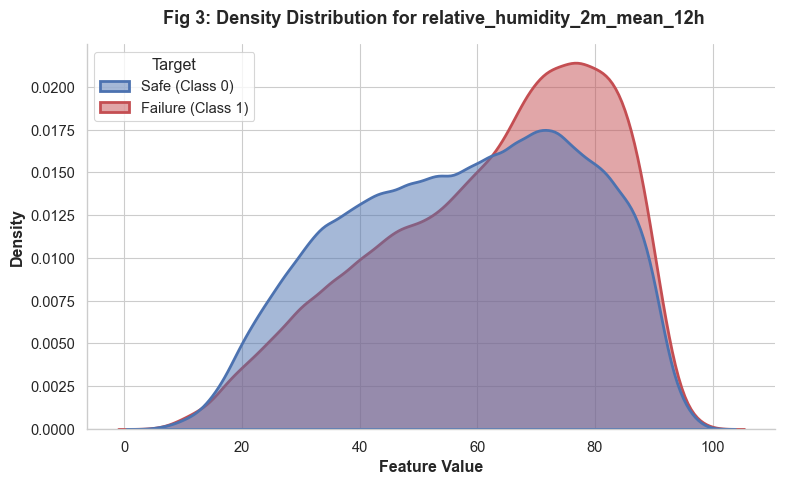

Plotting: precipitation_sum_24h...


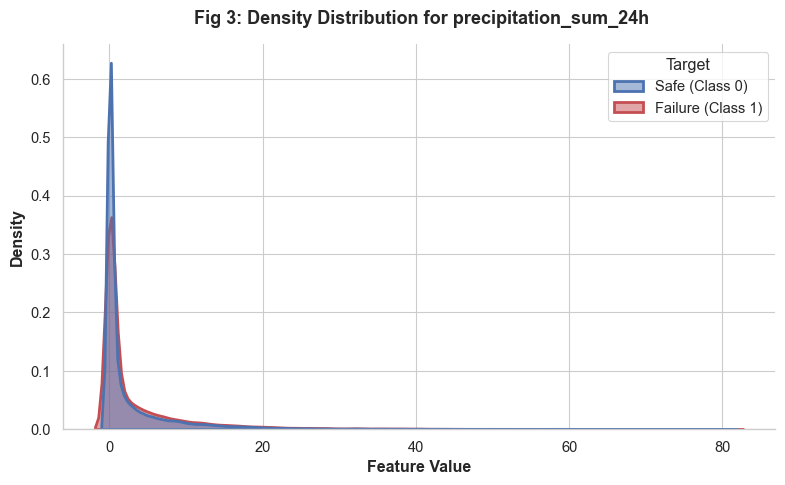

Plotting: soil_moisture_0_to_7cm_mean_24h...


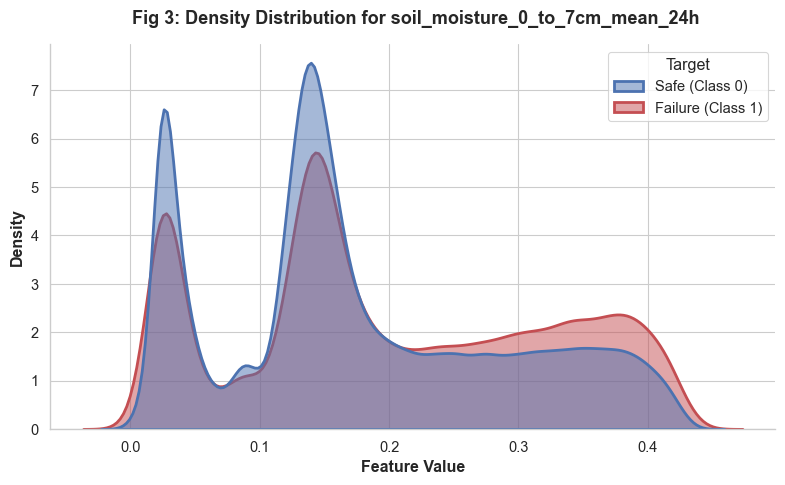

Plotting: soil_moisture_7_to_28cm_mean_24h...


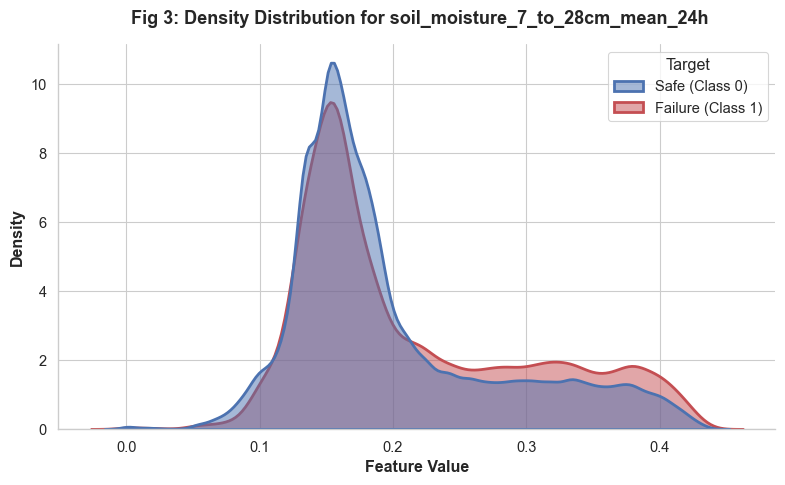

Plotting: relative_humidity_2m_mean_24h...


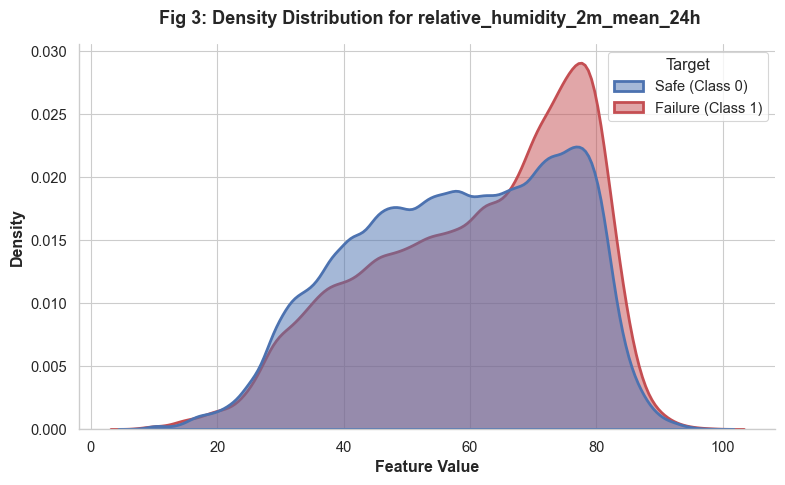

In [10]:
# Directory to save the plots
save_dir = "../plots/KDE_Signals"

# Overlaid Density Plot KDE - Violin plots
# Distribution of numerical data
# Blue represents class when city have a nice day
# Red represent class when city has an issue regarding water
def plot_all_kde_signals(X_train, y_train):
    # Directory to save the plots
    # Filter out binary/dummy variables (ex alcaldias)
    # KDE is not good for variables that are 0 or 1, so we'll focus on continuous features
    continuous_features = [col for col in X_train.columns if X_train[col].nunique() > 2]
    print(f"Filtered out binary columns. Generating plots for {len(continuous_features)} continuous features...")
    
    # Merge X and y for seaborn plotting
    df_plot = X_train[continuous_features].copy()
    df_plot['Target'] = y_train.values
    df_plot['Target'] = df_plot['Target'].map({0: 'Safe (Class 0)', 1: 'Failure (Class 1)'})
    
    # Setup the canvas style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    colors = ['#4C72B0', '#C44E52'] # Muted Blue and Red
    
    # Loop to plot all features
    for feature in continuous_features:
        print(f"Plotting: {feature}...")
        
        # Single figure for each feature
        fig, ax = plt.subplots(figsize=(8, 5))
        
        sns.kdeplot(
            data=df_plot,
            x=feature,
            hue='Target',
            fill=True,
            common_norm=False, 
            palette=colors,
            alpha=0.5,         
            linewidth=2,
            ax=ax
        )
        
        # Formatting
        ax.set_title(f' Fig 3: Density Distribution for {feature}', fontsize=13, fontweight='bold', pad=15)
        ax.set_ylabel('Density', fontweight='bold')
        ax.set_xlabel('Feature Value', fontweight='bold')
        
        sns.despine()
        plt.tight_layout()
        
        # Save individually at publication quality (300 DPI)
        file_path = os.path.join(save_dir, f'KDE_{feature}.png')
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        
        plt.show() 
        
        # Close figure to free RAM
        plt.close(fig)
        

# --- EXECUTION ---
plot_all_kde_signals(X_train, y_train)

In [11]:
len(df_ml.columns)

35

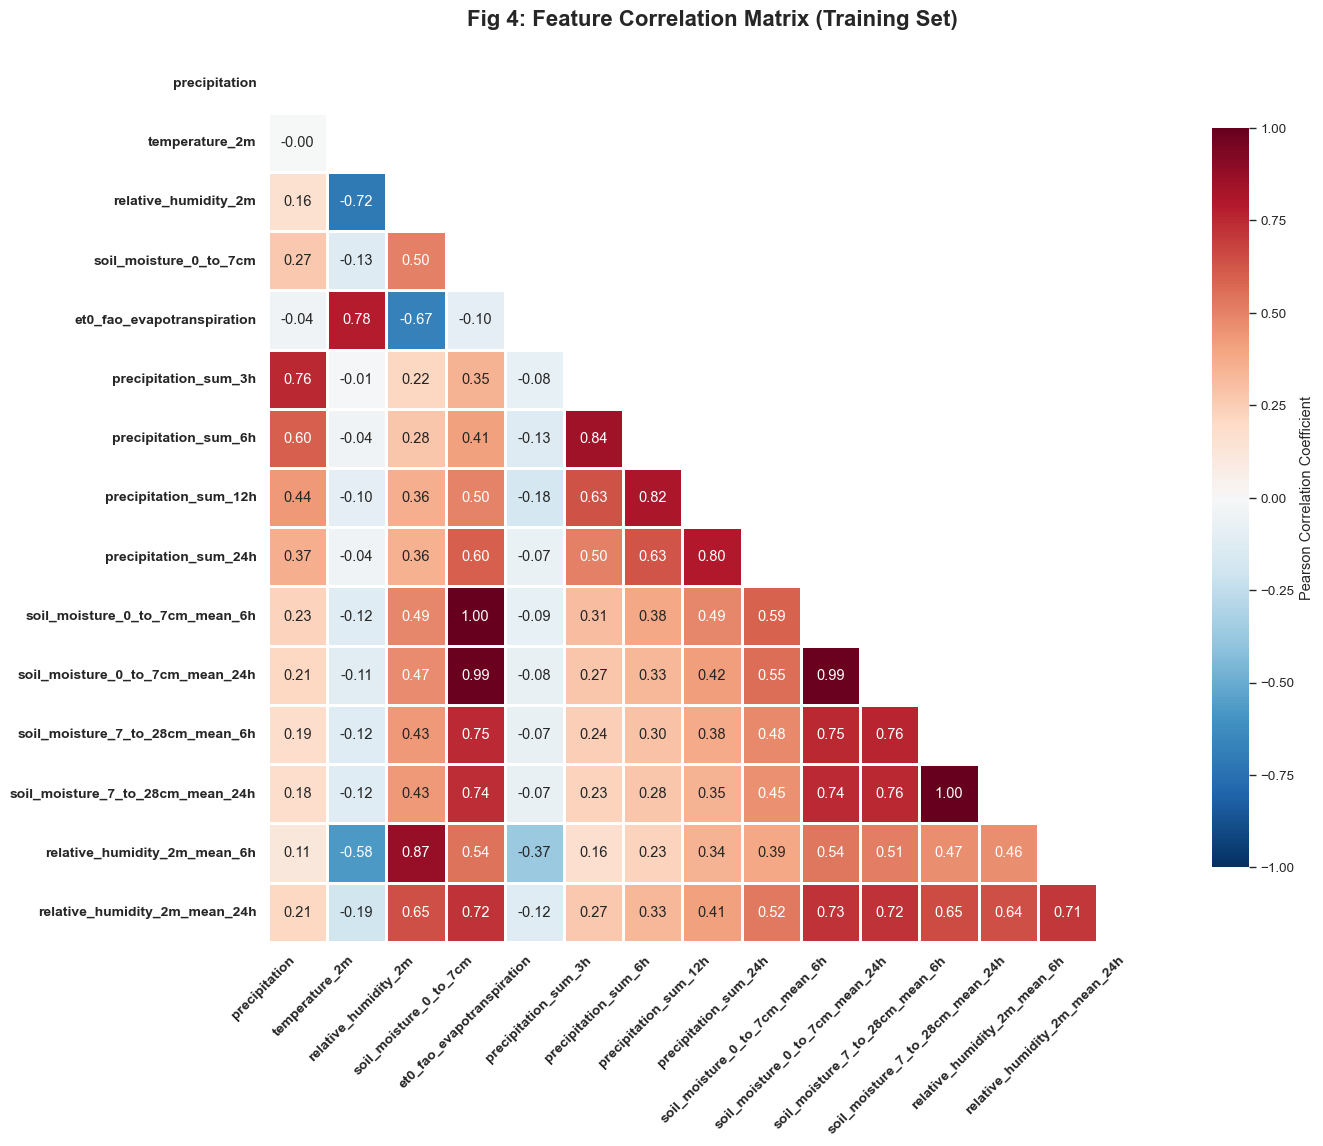

In [12]:
# Correlation Heatmap: Multicollinearity proof to justify rolling window feature engineering

def plot_correlation_heatmap(X_train, numerical_features):

    # Filter to only use numerical values for the correlation matrix
    df_numeric = X_train[numerical_features].copy()

    # Calculate Pearson Correlation matrix
    corr_matrix = df_numeric.corr(method='pearson')

    # Triangle to hide duplicate information (since correlation matrix is symmetric)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Canvas setup according to the paper's style guidelines
    sns.set_theme(style="white", context="paper", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(14, 12))

    # Colormap setup: Diverging palette centered at 0, with red for positive and blue for negative correlations
    cmap = sns.color_palette("RdBu_r", as_cmap=True)

    # Heatmap
    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap=cmap,
        center=0,
        vmax=1.0,
        vmin=-1.0,
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=1.0,
        cbar_kws={"shrink": .75, "label": "Pearson Correlation Coefficient"}
    )

    # Titles and formatting
    ax.set_title('Fig 4: Feature Correlation Matrix (Training Set)',
                 fontsize=16, fontweight='bold', pad=20)

    # Rotate the x-axis labels so no overlap
    plt.xticks(rotation=45, ha='right', fontweight='bold', fontsize=10)
    plt.yticks(fontweight='bold', fontsize=10)

    # Paper quality
    plt.tight_layout()
    plt.savefig('../plots/EDA_4_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# Use only numerical values
mis_variables_numericas = [
    'precipitation', 'temperature_2m', 'relative_humidity_2m',
    'soil_moisture_0_to_7cm', 'et0_fao_evapotranspiration',
    'precipitation_sum_3h', 'precipitation_sum_6h',
    'precipitation_sum_12h', 'precipitation_sum_24h',
    'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_0_to_7cm_mean_24h',
    'soil_moisture_7_to_28cm_mean_6h', 'soil_moisture_7_to_28cm_mean_24h',
    'relative_humidity_2m_mean_6h', 'relative_humidity_2m_mean_24h'
]

# Run the plotting function
plot_correlation_heatmap(X_train, mis_variables_numericas)

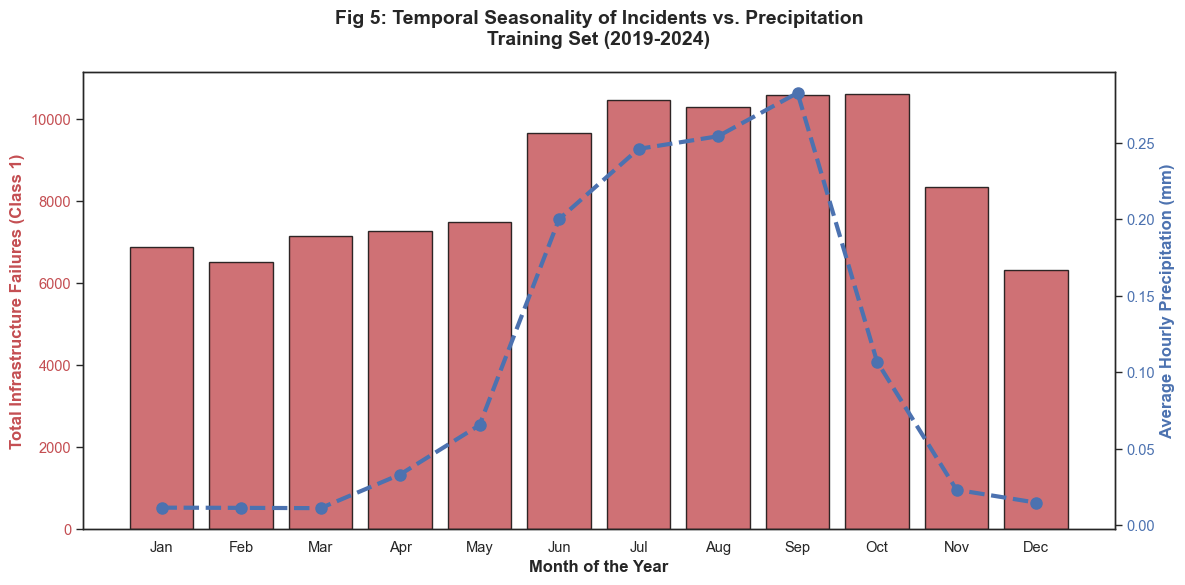

In [13]:
# Temporal Seasonality: The Reality Proof that the frequency of incidents perfectly tracks the rainy season
def plot_temporal_seasonality(X_train, y_train):

    # Temporaly merge columns for plotting
    # Usa of target, raw precipitation, and month for the plot
    df_plot = X_train[['mes', 'precipitation']].copy()
    df_plot['Target'] = y_train.values

    # Calculate metrics per month
    # Total incidents = sum of Target (1 for failure, 0 for safe)
    # Avg rain = mean of precipitation across all hours in that month
    monthly_stats = df_plot.groupby('mes').agg(
        Total_Incidents=('Target', 'sum'),
        Avg_Precipitation=('precipitation', 'mean')
    ).reset_index()

    # Map month numbers to actual names for readability
    monthly_stats['Month_Name'] = monthly_stats['mes'].apply(lambda x: calendar.month_abbr[x])

    # Start canvas with the paper's style guidelines
    sns.set_theme(style="white", context="paper", font_scale=1.2)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot incidents as bars on the primary y-axis
    color_incidents = '#C44E52' # Muted Red
    ax1.bar(monthly_stats['Month_Name'], monthly_stats['Total_Incidents'],
            color=color_incidents, alpha=0.8, edgecolor='black', linewidth=1)

    ax1.set_xlabel('Month of the Year', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Total Infrastructure Failures (Class 1)',
                   color=color_incidents, fontweight='bold', fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_incidents)

    # Plot the precipitation on the secondary y-axis
    ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
    color_rain = '#4C72B0' # Muted Blue

    # Plotting the line with markers for visibility
    ax2.plot(monthly_stats['Month_Name'], monthly_stats['Avg_Precipitation'],
             color=color_rain, marker='o', linewidth=3, markersize=8,
             linestyle='--', label='Avg Precipitation')

    ax2.set_ylabel('Average Hourly Precipitation (mm)',
                   color=color_rain, fontweight='bold', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_rain)
    ax2.grid(False) # Turn off grid for the secondary axis to avoid clutter

    # Titles and formatting
    plt.title('Fig 5: Temporal Seasonality of Incidents vs. Precipitation\nTraining Set (2019-2024)',
              fontsize=14, fontweight='bold', pad=20)

    # Save at publication quality
    fig.tight_layout()
    plt.savefig('../plots/EDA_5_Temporal_Seasonality.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_temporal_seasonality(X_train, y_train)